In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import linregress

blog_visuals = Path("visuals")
blog_visuals.mkdir(parents=True, exist_ok=True)

FIG_SIZE = (8.8, 5.6)
EXPORT_DPI = 220
THUMBNAIL_SIZE = (11, 6.3)
THUMBNAIL_DPI = 100

plt.rcParams.update({"axes.titlesize": 14, "axes.labelsize": 13,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11,})

In [23]:
def match_probs(elo_a, elo_b):
    elo_diff = elo_a - elo_b
    expected_score = 1 / (1 + 10 ** (-elo_diff / 400))
    p_draw = 0.29 * np.exp(-((elo_diff) / 350) ** 2)
    p_win = max(0.0, expected_score - 0.5 * p_draw)
    p_loss = max(0.0, 1 - p_win - p_draw)
    return p_win, p_draw, p_loss

df = pd.read_csv("data/teams.csv")
df["knockouts"] = pd.to_numeric(df["knockouts"], errors="coerce")

qualified = df[df["bracket"].notna()].copy()
qualified["bracket"] = qualified["bracket"].astype(int)

In [24]:
group_expected_rows = []
for (year, group), g in df.groupby(["year", "group"], sort=False):
    teams = g[["country", "elo"]].to_dict("records")
    for team in teams:
        expected_points = 0.0
        for opp in teams:
            if opp["country"] == team["country"]:
                continue
            p_win, p_draw, _ = match_probs(team["elo"], opp["elo"])
            expected_points += 3 * p_win + p_draw
        group_expected_rows.append({
            "year": year,
            "country": team["country"],
            "expected_group_points": expected_points,
        })
group_expected = pd.DataFrame(group_expected_rows)

In [25]:
rng = np.random.default_rng(42)
n_sims = 50000
knockout_expected_rows = []

for year, yq in qualified.groupby("year", sort=False):
    yq = yq.sort_values("bracket").reset_index(drop=True)
    teams = yq["country"].tolist()
    elo_lookup = yq.set_index("country")["elo"].to_dict()
    win_totals = {team: 0.0 for team in teams}

    for _ in range(n_sims):
        wins = {team: 0 for team in teams}
        current_round = teams.copy()

        while len(current_round) > 1:
            next_round = []
            for i in range(0, len(current_round), 2):
                team_a = current_round[i]
                team_b = current_round[i + 1]
                p_win, _, p_loss = match_probs(elo_lookup[team_a], elo_lookup[team_b])
                p_advance_a = p_win / (p_win + p_loss)
                winner = team_a if rng.random() < p_advance_a else team_b
                wins[winner] += 1
                next_round.append(winner)
            current_round = next_round

        for team in teams:
            win_totals[team] += wins[team]

    for team in teams:
        knockout_expected_rows.append({
            "year": year,
            "country": team,
            "expected_knockout_wins": win_totals[team] / n_sims,
        })

knockout_expected = pd.DataFrame(knockout_expected_rows)

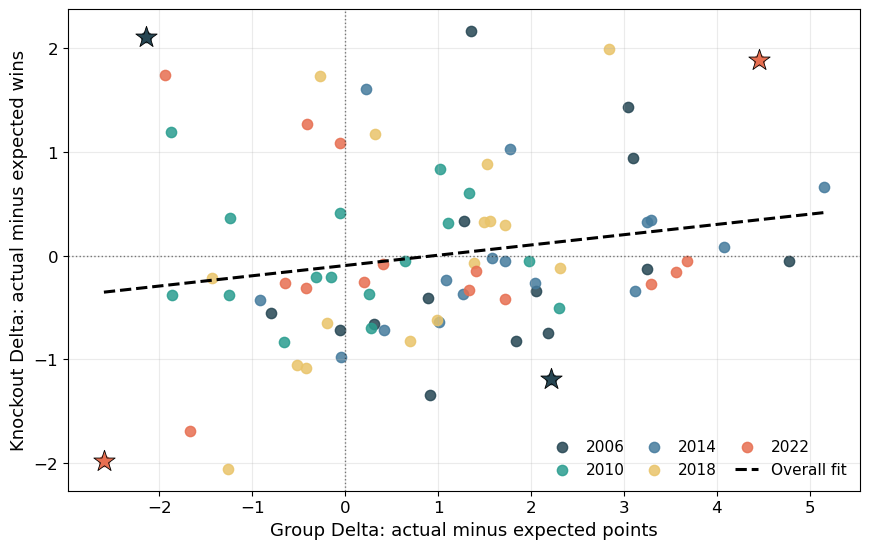

,Corner,Year,Country,Group Delta,Knockout Delta
0,Top Left,2006,France,-2.141854,2.10078
1,Top Right,2022,Morocco,4.455284,1.87768
2,Bottom Left,2022,Spain,-2.594970,-1.97960
3,Bottom Right,2006,Brazil,2.218728,-1.19278


In [26]:
plot_df = (
    qualified
    .merge(group_expected, on=["year", "country"], how="left")
    .merge(knockout_expected, on=["year", "country"], how="left")
    .sort_values(["year", "bracket"])
    .reset_index(drop=True)
)

plot_df["delta_group"] = plot_df["points"] - plot_df["expected_group_points"]
plot_df["delta_knockout"] = plot_df["knockouts"] - plot_df["expected_knockout_wins"]

fig, ax = plt.subplots(figsize=FIG_SIZE)
colors = {
    2006: "#264653",
    2010: "#2a9d8f",
    2014: "#457b9d",
    2018: "#e9c46a",
    2022: "#e76f51",
}

for year, g in plot_df.groupby("year", sort=True):
    x = g["delta_group"].to_numpy()
    y = g["delta_knockout"].to_numpy()
    color = colors.get(year, "#444444")

    ax.scatter(x, y, s=55, alpha=0.85, color=color, label=str(year))

corner_idx = {
    "Top Left": (plot_df["delta_knockout"] - plot_df["delta_group"]).idxmax(),
    "Top Right": (plot_df["delta_knockout"] + plot_df["delta_group"]).idxmax(),
    "Bottom Left": (plot_df["delta_knockout"] + plot_df["delta_group"]).idxmin(),
    "Bottom Right": (plot_df["delta_group"] - 3*plot_df["delta_knockout"]).idxmax(),
}

corner_points = []
for corner, idx in corner_idx.items():
    row = plot_df.loc[idx]
    corner_points.append({
        "Corner": corner,
        "Year": int(row["year"]),
        "Country": row["country"],
        "Group Delta": row["delta_group"],
        "Knockout Delta": row["delta_knockout"],
    })
    star_color = colors.get(int(row["year"]), "#444444")
    ax.scatter(
        row["delta_group"],
        row["delta_knockout"],
        marker="*",
        s=260,
        color=star_color,
        edgecolors="black",
        linewidths=0.6,
        zorder=6,
    )

x_all = plot_df["delta_group"].to_numpy()
y_all = plot_df["delta_knockout"].to_numpy()
m_all, b_all = np.polyfit(x_all, y_all, 1)
x_all_line = np.linspace(x_all.min(), x_all.max(), 100)
y_all_line = m_all * x_all_line + b_all
ax.plot(x_all_line, y_all_line, color="black", linewidth=2.2, linestyle="--", label="Overall fit")

ax.axhline(0, color="black", linewidth=1, linestyle=":", alpha=0.5)
ax.axvline(0, color="black", linewidth=1, linestyle=":", alpha=0.5)
ax.set_xlabel("Group Delta: actual minus expected points")
ax.set_ylabel("Knockout Delta: actual minus expected wins")
ax.legend(frameon=False, ncol=3, handlelength=1.5, columnspacing=1.2)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

corner_df = pd.DataFrame(corner_points)
display(corner_df)

In [27]:
results = []
for year, g in plot_df.groupby("year", sort=True):
    x = g["delta_group"].to_numpy()
    y = g["delta_knockout"].to_numpy()
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    results.append({
        "Year": int(year),
        "Slope": slope,
        "Intercept": intercept,
        "R²": r_value ** 2,
        "p-value": p_value,
        "n": len(g),
    })

x_all = plot_df["delta_group"].to_numpy()
y_all = plot_df["delta_knockout"].to_numpy()
slope_all, intercept_all, r_value_all, p_value_all, std_err_all = linregress(x_all, y_all)
results.append({
    "Year": "Overall",
    "Slope": slope_all,
    "Intercept": intercept_all,
    "R²": r_value_all ** 2,
    "p-value": p_value_all,
    "n": len(plot_df),
})

results_df = pd.DataFrame(results)
display(results_df)

,Year,Slope,Intercept,R²,p-value,n
0,2006,-0.054460,0.082531,0.007079,0.756709,16
1,2010,-0.018013,0.001740,0.001640,0.881625,16
2,2014,0.130886,-0.237779,0.100109,0.232510,16
3,2018,0.454157,-0.305774,0.282490,0.034109,16
4,2022,0.139245,-0.107345,0.079114,0.291278,16
5,Overall,0.098831,-0.096320,0.035124,0.095977,80


In [ ]:
main_plot_path = blog_visuals / "group-vs-knockout-overperformance.png"
fig.savefig(main_plot_path, dpi=EXPORT_DPI)
print(f"Saved figure: {main_plot_path.resolve()}")

thumbnail_path = blog_visuals / "thumbnail-group-stage.png"
original_size = fig.get_size_inches().copy()
fig.set_size_inches(*THUMBNAIL_SIZE)
fig.savefig(thumbnail_path, dpi=THUMBNAIL_DPI)
fig.set_size_inches(*original_size)
print(f"Saved thumbnail: {thumbnail_path.resolve()}")

Saved figure: /Users/vik.shirvaikar/Desktop/vshirvaikar.github.io/blog/2026.06 WC Momentum/visuals/group-vs-knockout-overperformance.png
Saved thumbnail: /Users/vik.shirvaikar/Desktop/vshirvaikar.github.io/blog/2026.06 WC Momentum/visuals/thumbnail-group-stage.png
![figure](visuals/group-vs-knockout-overperformance.png)
![Thumbnail](visuals/thumbnail-group-stage.png)


## Secondary Result (Not Used In Final Article)

This section ports over a side analysis from the WC Chaos notebook.

It checks year-by-year calibration of expected group-stage points vs actual group-stage points, and highlights each year's biggest over/under performers. We did not use this in the final momentum story, but it is kept here as an additional diagnostic.

In [29]:
groups26 = pd.read_csv("data/groups26.csv")
groups26["group"] = groups26["group"].astype(str).str.strip().str.upper()
groups26["points"] = pd.to_numeric(groups26["points"], errors="coerce")

wc_secondary = pd.concat(
    [
        df[df["year"] != 2026].copy(),
        groups26,
    ],
    ignore_index=True,
)
wc_secondary["group"] = wc_secondary["group"].astype(str).str.strip().str.upper()
wc_secondary["points"] = pd.to_numeric(wc_secondary["points"], errors="coerce")

wc_group_expected_rows = []
for (year, group), g in wc_secondary.groupby(["year", "group"], sort=False):
    teams = g[["country", "elo"]].to_dict("records")
    for team in teams:
        expected_points = 0.0
        for opp in teams:
            if opp["country"] == team["country"]:
                continue
            p_win, p_draw, _ = match_probs(team["elo"], opp["elo"])
            expected_points += 3 * p_win + p_draw
        wc_group_expected_rows.append(
            {
                "year": year,
                "country": team["country"],
                "expected_group_points": expected_points,
            }
        )

wc_group_expected = pd.DataFrame(wc_group_expected_rows)

group_eval_df = wc_secondary.merge(wc_group_expected, on=["year", "country"], how="left")
wc_years = sorted(group_eval_df["year"].dropna().unique())

wc_group_metrics_rows = []
for year in wc_years:
    gy = group_eval_df[group_eval_df["year"] == year].dropna(subset=["points", "expected_group_points"])
    mae = (gy["points"] - gy["expected_group_points"]).abs().mean()
    r2 = linregress(gy["expected_group_points"], gy["points"]).rvalue ** 2
    wc_group_metrics_rows.append(
        {
            "Year": int(year),
            "MAE": mae,
            "R²": r2,
            "n": len(gy),
        }
    )

wc_group_metrics_df = pd.DataFrame(wc_group_metrics_rows).sort_values("Year").reset_index(drop=True)
display(wc_group_metrics_df[["Year", "R²", "MAE"]])

,Year,R²,MAE
0,2006,0.453485,1.807873
1,2010,0.597785,1.126133
2,2014,0.374198,1.822837
3,2018,0.716029,1.099213
4,2022,0.114546,1.863941
5,2026,0.532934,1.440472


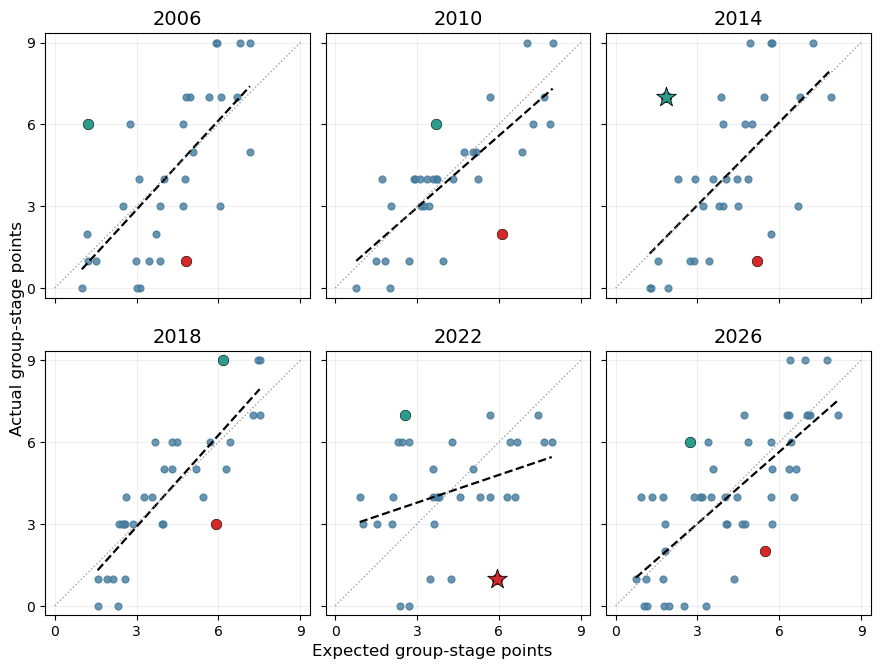

,Year,R²,MAE
0,2006,0.453485,1.807873
1,2010,0.597785,1.126133
2,2014,0.374198,1.822837
3,2018,0.716029,1.099213
4,2022,0.114546,1.863941
5,2026,0.532934,1.440472


,Year,Worst Underperformer,Worst Delta,Best Overperformer,Best Delta
0,2006,Iran,-3.823716,Ghana,4.777942
1,2010,Italy,-4.130914,Japan,2.304967
2,2014,England,-4.200242,Costa Rica,5.154843
3,2018,Germany,-2.911459,Croatia,2.845422
4,2022,Denmark,-4.940336,Morocco,4.455284
5,2026,Uruguay,-3.483775,United States,3.284774


In [30]:
wc_subplot_height = 7.2
axis_pad = 0.35

fig_wc, axes = plt.subplots(2, 3, figsize=(FIG_SIZE[0], wc_subplot_height), sharex=True, sharey=True)
axes = axes.flatten()

group_eval_plot_df = group_eval_df.dropna(subset=["expected_group_points", "points"]).copy()
group_eval_plot_df["residual"] = group_eval_plot_df["points"] - group_eval_plot_df["expected_group_points"]

worst_row = group_eval_plot_df.loc[group_eval_plot_df["residual"].idxmin()]
best_row = group_eval_plot_df.loc[group_eval_plot_df["residual"].idxmax()]

wc_extremes_rows = []
for ax_wc, year in zip(axes, wc_years):
    gy = group_eval_plot_df[group_eval_plot_df["year"] == year]
    if len(gy) == 0:
        ax_wc.set_title(str(int(year)))
        ax_wc.axis("off")
        continue

    x = gy["expected_group_points"].to_numpy()
    y = gy["points"].to_numpy()

    ax_wc.scatter(x, y, s=24, alpha=0.8, color="#457b9d")
    if len(gy) >= 2:
        m_wc, b_wc = np.polyfit(x, y, 1)
        x_line_wc = np.linspace(x.min(), x.max(), 100)
        ax_wc.plot(x_line_wc, m_wc * x_line_wc + b_wc, color="black", linewidth=1.6, linestyle="--")

    worst_row_y = gy.loc[gy["residual"].idxmin()]
    best_row_y = gy.loc[gy["residual"].idxmax()]
    ax_wc.scatter(worst_row_y["expected_group_points"], worst_row_y["points"], s=58, color="#d62828", edgecolors="black", linewidths=0.4, zorder=5)
    ax_wc.scatter(best_row_y["expected_group_points"], best_row_y["points"], s=58, color="#2a9d8f", edgecolors="black", linewidths=0.4, zorder=5)

    wc_extremes_rows.append(
        {
            "Year": int(year),
            "Worst Underperformer": worst_row_y["country"],
            "Worst Delta": worst_row_y["residual"],
            "Best Overperformer": best_row_y["country"],
            "Best Delta": best_row_y["residual"],
        }
    )

    if int(worst_row["year"]) == int(year):
        ax_wc.scatter(worst_row["expected_group_points"], worst_row["points"], marker="*", s=220, color="#d62828", edgecolors="black", linewidths=0.6, zorder=6)
    if int(best_row["year"]) == int(year):
        ax_wc.scatter(best_row["expected_group_points"], best_row["points"], marker="*", s=220, color="#2a9d8f", edgecolors="black", linewidths=0.6, zorder=6)

    ax_wc.plot([0, 9], [0, 9], color="#888888", linewidth=1, linestyle=":", alpha=0.8)
    ax_wc.set_title(str(int(year)))
    ax_wc.grid(alpha=0.2)
    ax_wc.set_xlim(-axis_pad, 9 + axis_pad)
    ax_wc.set_ylim(-axis_pad, 9 + axis_pad)
    ax_wc.set_xticks([0, 3, 6, 9])
    ax_wc.set_yticks([0, 3, 6, 9])
    ax_wc.tick_params(labelsize=10)
    ax_wc.set_aspect("equal", adjustable="box")

fig_wc.supxlabel("Expected group-stage points", y=0.04)
fig_wc.supylabel("Actual group-stage points", x=0.02)
fig_wc.subplots_adjust(left=0.06, right=0.998, bottom=0.08, top=0.93, wspace=0.06, hspace=0.08)
plt.show()

display(wc_group_metrics_df[["Year", "R²", "MAE"]])

wc_extremes_df = pd.DataFrame(wc_extremes_rows).sort_values("Year").reset_index(drop=True)
display(wc_extremes_df)